In [14]:
!pip install shapiq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 148.6 MB/s eta 0:00:00


In [15]:
import shap
import xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shapiq

# Showcase of Python packages for attribution methods

In this notebook, we will showcase how to use the most popular python package to compute attribution based on cooperative games (mainly Shapley values).


# Data and model

We are going to work with the [Adult dataset](https://archive.ics.uci.edu/dataset/2/adult).


## Getting to know the data



### Overview

The **Adult Income** dataset, a.k.a the *Census Income* dataset, is derived from the 1994 U.S. Census Bureau database. It contains demographic and socioeconomic information about **48,842 individuals**. The version provided by `shap.datasets.adult()` is a cleaned subset of **32,561 individuals** with **14 features**.

---

### Prediction Task

The goal is to predict whether an individual's annual income **exceeds $50,000**, based on their demographic and employment characteristics.

This is a **binary classification** problem:

| Label | Meaning |
|-------|---------|
| `True` | Income **> 50K/year** |
| `False` | Income **≤ 50K/year** |

The dataset is **moderately imbalanced**: roughly **75% of individuals earn ≤ 50K**, and **25% earn > 50K**.

---

### Numeric covariates

| Feature | Description |
|---------|-------------|
| `Age` | Age of the individual (years) |
| `Education-Num` | Number of years of education (encoded as an integer) |
| `Capital Gain` | Capital gains recorded in the past year |
| `Capital Loss` | Capital losses recorded in the past year|
| `Hours per week` | Number of hours worked per week |

### Categorical covariates

| Feature | Description | Example values |
|---------|-------------|----------------|
| `Workclass` | Employment sector | Private, Self-emp, Gov, Never-worked |
| `Education` | Highest level of education attained | Bachelors, HS-grad, Masters, Doctorate |
| `Marital Status` | Marital status | Married-civ-spouse, Divorced, Never-married |
| `Occupation` | Type of occupation | Exec-managerial, Craft-repair, Sales |
| `Relationship` | Relationship role within the household | Husband, Wife, Own-child, Not-in-family |
| `Race` | Self-reported race | White, Black, Asian-Pac-Islander, Other |
| `Sex` | Sex | Male, Female |
| `Country` | Country of origin | United-States, Mexico, India, ... |

---

In [2]:
# ── Global style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE_WIDE = (14, 4)
FIGSIZE_MED  = (10, 5)
COLORS = {True: "#ED7D31", False: "#5A9BD5"}   # True = ">50K"
LABELS = {True: "> 50K", False: "≤ 50K"}

In [3]:
# Loading the dataset

# shap.datasets.adult() returns:
#   X : pd.DataFrame  — 14 features (mix of numeric and categorical)
#   y : pd.Series     — bool target  (True = income > 50K)
X_, y = shap.datasets.adult()

# Cast categorical columns to pandas Categorical dtype
cat_cols = ["Workclass", "Marital Status", "Occupation", "Relationship", "Race", "Sex", "Country"]
num_cols = ["Age", "Education-Num", "Capital Gain", "Capital Loss", "Hours per week"]
X = X_.copy()
for col in cat_cols:
    X[col] = X[col].astype("category")

# Rebuild a single DataFrame for EDA convenience
df = X.copy()
df["income"] = y

TARGET_COL = "income"
print(f"Rows        : {df.shape[0]:,}")
print(f"Features    : {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Target      : '{TARGET_COL}'  —  bool  (True = >50K)")
print()
df.head()

Rows        : 32,561
Features    : 12  (5 numeric, 7 categorical)
Target      : 'income'  —  bool  (True = >50K)



,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,income
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39,False
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39,False
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39,False
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39,False
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5,False


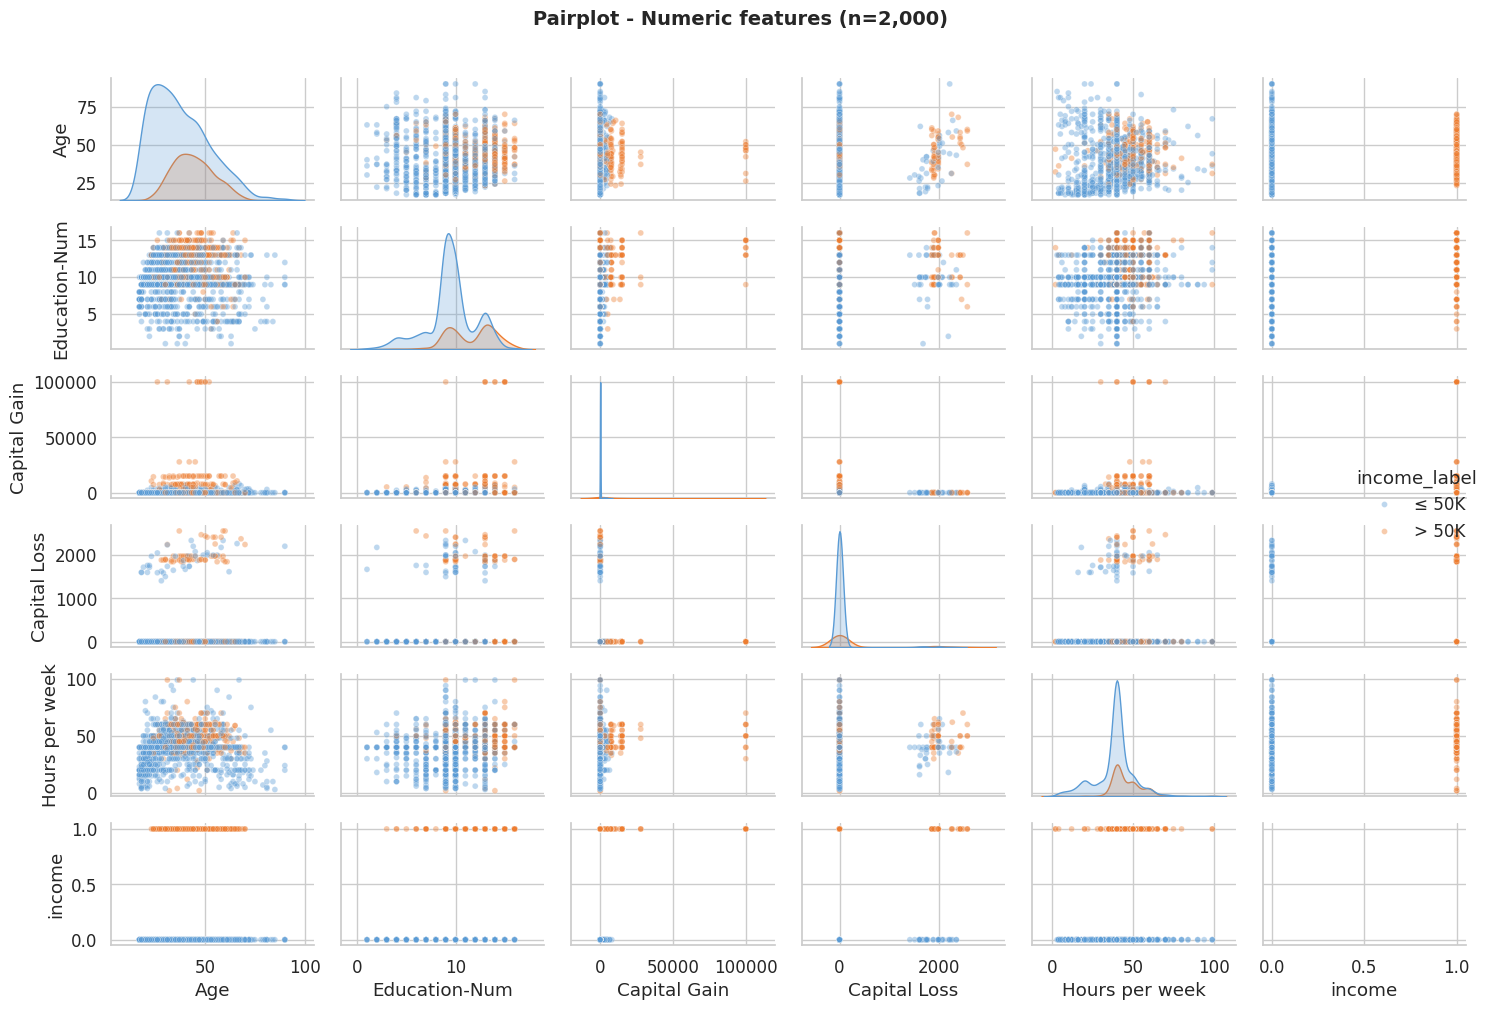

In [4]:
# Scatterplots for numerical features

# Subsample to keep rendering fast while preserving class proportions
sample = df[num_cols + [TARGET_COL]].sample(2000, random_state=42)
sample["income_label"] = sample[TARGET_COL].map(LABELS)

g = sns.pairplot(sample, hue="income_label",
                 palette={LABELS[True]: COLORS[True], LABELS[False]: COLORS[False]},
                 plot_kws={"alpha": 0.4, "s": 18},
                 diag_kind="kde")

g.figure.set_size_inches(15, 10)   # ← force la taille totale de la figure
g.figure.suptitle("Pairplot - Numeric features (n=2,000)", y=1.01,
                   fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


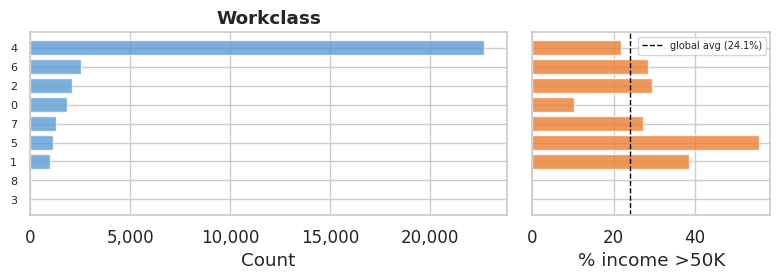

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


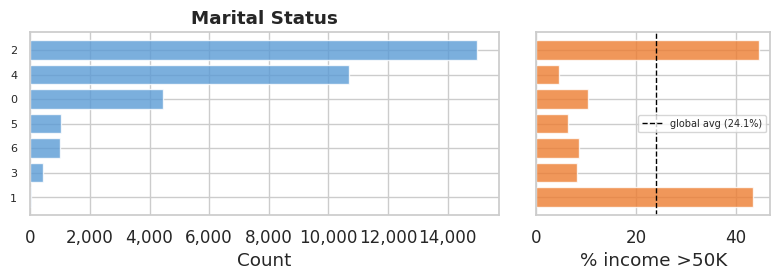

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


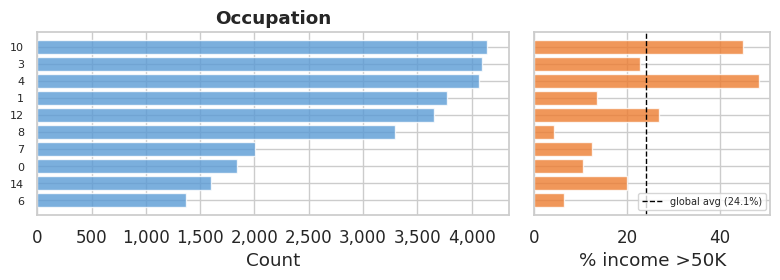

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


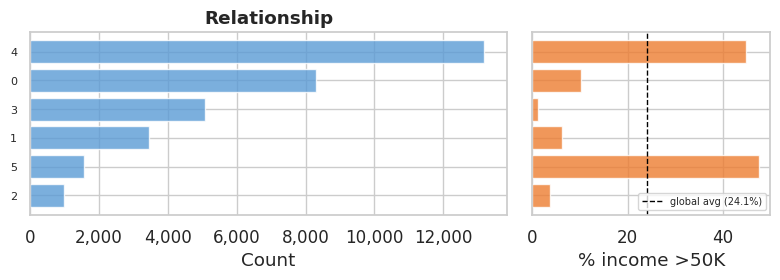

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


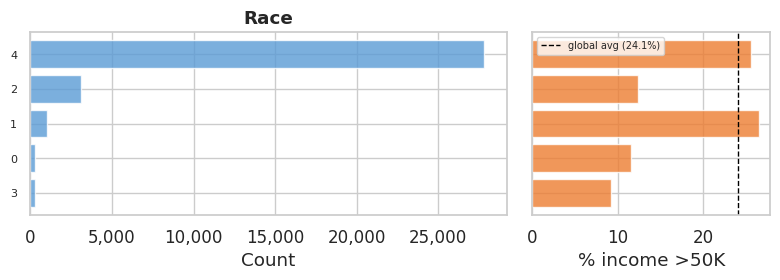

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


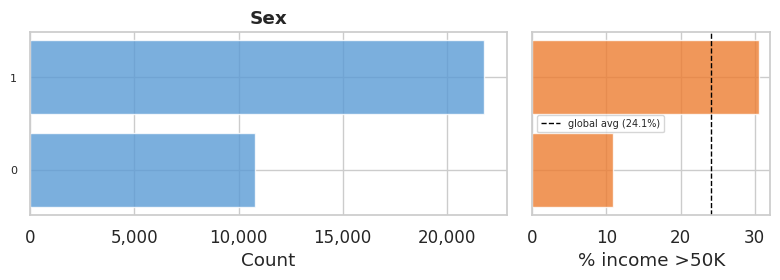

/tmp/ipykernel_2811/3068266359.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = (df[df[TARGET_COL]].groupby(df[col]).size()
/tmp/ipykernel_2811/3068266359.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .div(df.groupby(col).size())


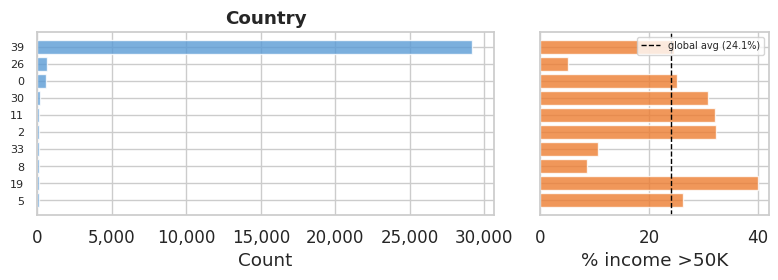

In [5]:
# Categorical features


# For each modality we plot:
#   Left  — raw count (how common the group is)
#   Right — % earning >50K (raw signal that Shapley values will later explain)
global_rate = y.mean() * 100

def plot_cat_feature(ax_bar, ax_rate, col, top_n=10):
    vc   = df[col].value_counts().head(top_n)
    rate = (df[df[TARGET_COL]].groupby(df[col]).size()
                               .div(df.groupby(col).size())
                               .loc[vc.index] * 100)
    y_pos = np.arange(len(vc))

    # Frequency bar
    ax_bar.barh(y_pos, vc.values, color="#5A9BD5", alpha=0.8)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(vc.index, fontsize=8)
    ax_bar.invert_yaxis()
    ax_bar.set_title(col, fontweight="bold")
    ax_bar.set_xlabel("Count")
    ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # >50K rate bar + global average reference line
    ax_rate.barh(y_pos, rate.values, color="#ED7D31", alpha=0.8)
    ax_rate.set_yticks(y_pos)
    ax_rate.set_yticklabels([])
    ax_rate.invert_yaxis()
    ax_rate.set_xlabel("% income >50K")
    ax_rate.axvline(global_rate, color="black", linestyle="--",
                    linewidth=1, label=f"global avg ({global_rate:.1f}%)")
    ax_rate.legend(fontsize=7)

for col in cat_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3),
                                    gridspec_kw={"width_ratios": [2, 1]})
    plot_cat_feature(ax1, ax2, col)
    plt.tight_layout()
    plt.show()

## Predictive model

We are going to fit an XGBoost model on the whole dataset.

In [6]:
# Train an XGBoost model with categorical features
model = xgboost.XGBClassifier(enable_categorical=True, tree_method="hist")
model.fit(X, y);

# Train an XGBoost with categorical features assumed to be numerical
model_ = xgboost.XGBClassifier()
model_.fit(X_, y);

This model will play the role of the **black-box model**.

# SHAP (SHapley Additive exPlanations) package


**[SHAP](https://shap-community.readthedocs.io/en/latest/index.html)** is a Python library developed by Scott Lundberg and Su-In Lee, introduced in their 2017 NeurIPS paper
*"A Unified Approach to Interpreting Model Predictions"*.

The library implements several estimators, each designed for specific model families:

| Estimator | Target models | Key property |
|-----------|--------------|--------------|
| `TreeExplainer` | Tree ensembles (XGBoost, LightGBM, RF...) | Exact, polynomial-time |
| `LinearExplainer` | Linear models | Exact, closed-form |
| `DeepExplainer` | Neural networks (TensorFlow, PyTorch) | Approximate, backprop-based |
| `GradientExplainer` | Differentiable models | Approximate, gradient-based |
| `KernelExplainer` | Any model (black-box) | Model-agnostic, slower |
| `PermutationExplainer` | Any model (black-box) | Model-agnostic, antithetic sampling |

---

We are going to decompose the following prediction


In [7]:
INSTANCE_IDX = 4
x_instance = X.iloc[[INSTANCE_IDX]]
x_instance

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5


In [8]:
model.predict(x_instance)

array([0])

## Conditional Shapley using a Tree surrogate

=== Conditional Shapley ===
E[f(X)]        : -1.3009
Sum of φ_i     : 0.9057
f(x) - E[f(X)] : 1.7033


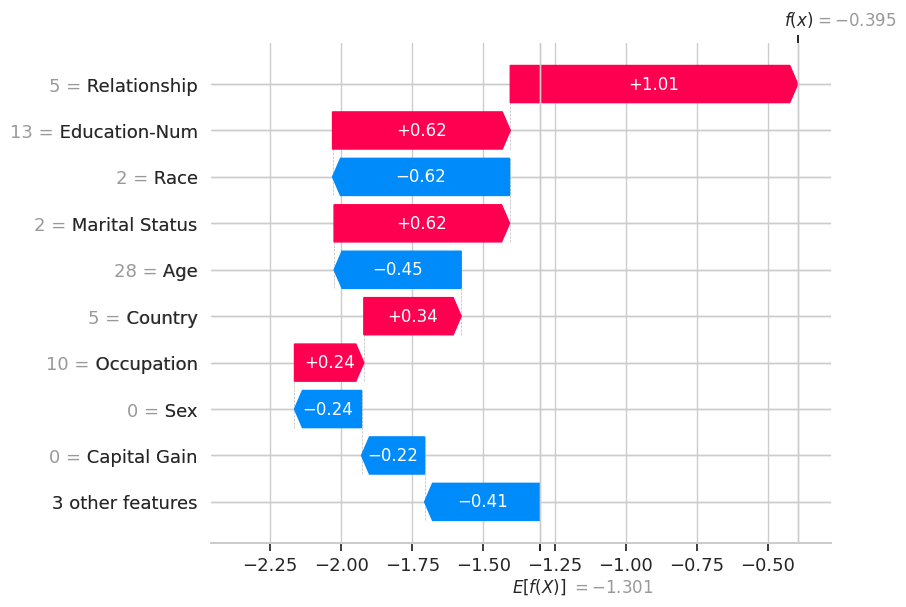

In [9]:
explainer_cond = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"   # ← conditional on tree paths
)
sv_cond = explainer_cond(x_instance)

print("=== Conditional Shapley ===")
print(f"E[f(X)]        : {explainer_cond.expected_value:.4f}")
print(f"Sum of φ_i     : {sv_cond.values[0].sum():.4f}")
print(f"f(x) - E[f(X)] : {model.predict_proba(x_instance)[0,1] - explainer_cond.expected_value:.4f}")

shap.plots.waterfall(sv_cond[0], show=True)

## Marginal Shapley values using a Tree Surrogate

=== Marginal (Interventional) Shapley ===
E[f(X)]        : -2.4072
Sum of φ_i     : 1.7162
f(x) - E[f(X)] : 2.8097


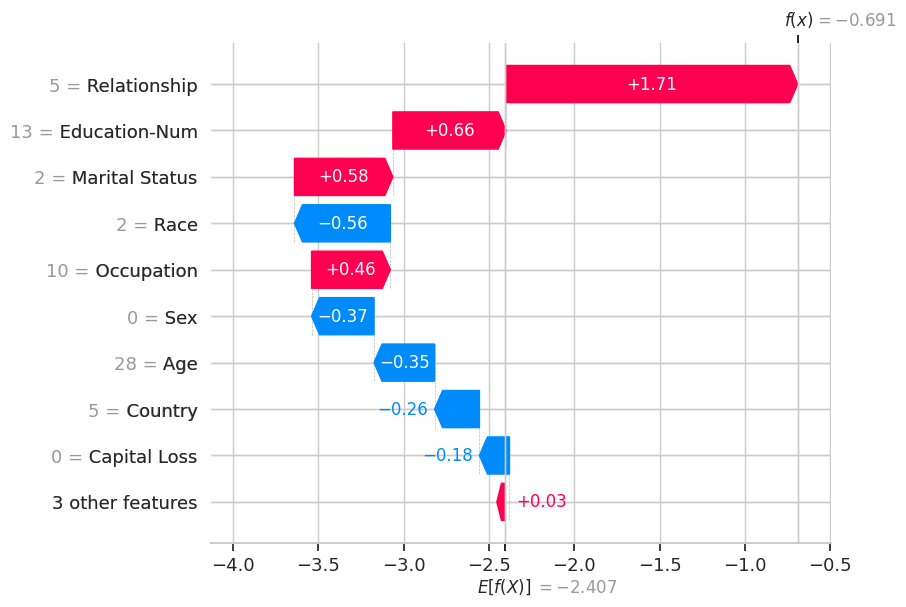

In [10]:
# Background sample to approximate the marginal distribution
background = shap.sample(X, 1000, random_state=42)

explainer_marg = shap.TreeExplainer(
    model_,
    data=background,
    feature_perturbation="interventional"        # ← DOES NOT WORK BECAUSE WE HAVE CATEGORICAL VARIABLES
)
sv_marg = explainer_marg(x_instance)

print("=== Marginal (Interventional) Shapley ===")
print(f"E[f(X)]        : {explainer_marg.expected_value:.4f}")
print(f"Sum of φ_i     : {sv_marg.values[0].sum():.4f}")
print(f"f(x) - E[f(X)] : {model.predict_proba(x_instance)[0,1] - explainer_marg.expected_value:.4f}")

shap.plots.waterfall(sv_marg[0], show=True)

## Baseline Shapley (mean individual)

=== Baseline Shapley ===
f(baseline)    : 0.0020
Sum of φ_i     : 0.3318
f(x) - f(b)    : 0.4004


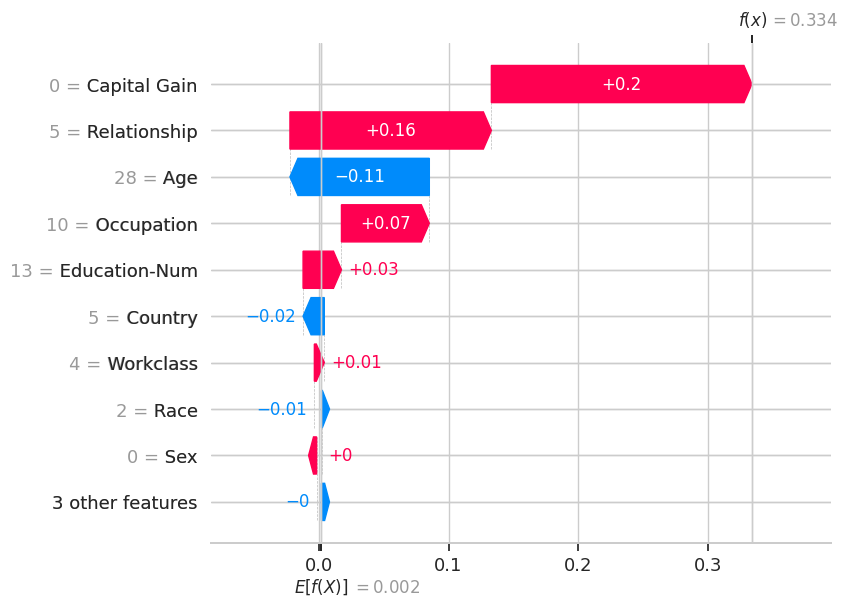

In [11]:
# Single reference point: the mean individual
baseline = X_.mean().to_frame().T

explainer_base = shap.KernelExplainer(
    lambda x: model_.predict_proba(x)[:, 1],     # output: P(income > 50K)
    baseline
)
sv_base_vals = explainer_base.shap_values(x_instance, nsamples=512, silent=True)

# Reconstruct an Explanation object for the waterfall plot
sv_base = shap.Explanation(
    values=sv_base_vals[0],
    base_values=explainer_base.expected_value,
    data=x_instance.values[0],
    feature_names=X_.columns.tolist()
)

print("=== Baseline Shapley ===")
print(f"f(baseline)    : {explainer_base.expected_value:.4f}")
print(f"Sum of φ_i     : {sv_base_vals[0].sum():.4f}")
print(f"f(x) - f(b)    : {model.predict_proba(x_instance)[0,1] - explainer_base.expected_value:.4f}")

shap.plots.waterfall(sv_base, show=True)

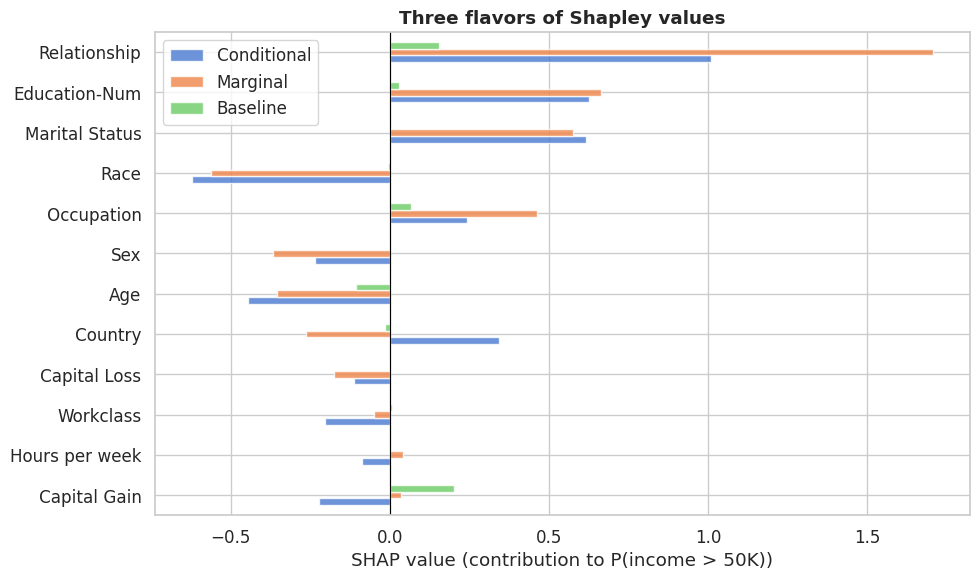

In [12]:
comparison = pd.DataFrame({
    "Conditional"  : sv_cond.values[0],
    "Marginal"     : sv_marg.values[0],
    "Baseline"     : sv_base_vals[0],
}, index=X.columns).sort_values("Marginal", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot.barh(ax=ax, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Three flavors of Shapley values",
             fontweight="bold")
ax.set_xlabel("SHAP value (contribution to P(income > 50K))")
plt.tight_layout()
plt.show()

Attributions differ greatly with the flavor of Shapley values. This is known as the **[XAI Disagreement Problem](https://proceedings.mlr.press/v238/laberge24a.html)**.

<div class="alert alert-warning">
⚠️ <strong>Remarks</strong><br>

- Baseline and Marginal Shapley values do not work with **models with categorical covariates**.
- It is not the prediction that is decomposed, but rather the **class probability** (this is why the attribution do not sum to 0 or 1).
</div>

# shapiq (Shapley Interactions) package

The **[shapiq](https://github.com/mmschlk/shapiq)** package computes the **Shapley interaction indices**: the allocations are defined over *coalitions* of covariates.

For a subset $S \subseteq N$ of features, shapiq estimates interaction indices using the **[Shapley Interaction Index]()** value:
$$\phi(S) = \sum_{A \subseteq D \setminus S} \frac{(|D| - |A| - |S|)!\; |A|!}{(|D| - |S| + 1)!} \sum_{L \subseteq S} (-1)^{|S| - |L|}\, v(A \cup L)$$

They generalize the standard Shapley value to higher-order effects. At order $k = 1$, all indices reduce to the classical Shapley values computed by SHAP. At order $k = 2$, they capture pairwise synergies; a positive value $\phi_{\{i,j\}} > 0$ indicates that features $i$ and $j$ jointly contribute *more* than the sum of their individual contributions.



The value function used by default is the **interventional (marginal) value function**: features outside $S$ are marginalized over a background distribution.

In [16]:
# ── Background sample for the interventional value function ──
background = shap.sample(X_, 1000, random_state=42).values   # ← .values

explainer_shapiq = shapiq.TabularExplainer(
    model=model_.predict_proba,
    data=background,
    index="SII",
    max_order=2 # Maximum number of interactions allowed
)

x_instance = X_.iloc[[INSTANCE_IDX]].values                  # ← .values
interaction_values = explainer_shapiq.explain(x_instance, budget=256)

print(interaction_values)

InteractionValues(
    index=SII, max_order=2, min_order=0, estimated=True, estimation_budget=256,
    n_players=12, baseline_value=0.2537500262260437,
    Top 10 interactions:
        (5,): 0.16801527433278202
        (2,): 0.10601705924257894
        (0, 2): 0.06158963940853045
        (5, 10): 0.05483077287529994
        (4,): 0.04971023182746743
        (4, 11): -0.05514251150662726
        (7, 11): -0.058811538647257446
        (5, 6): -0.06398553166455971
        (0,): -0.0753579551007338
        (6,): -0.09722219950924937
)


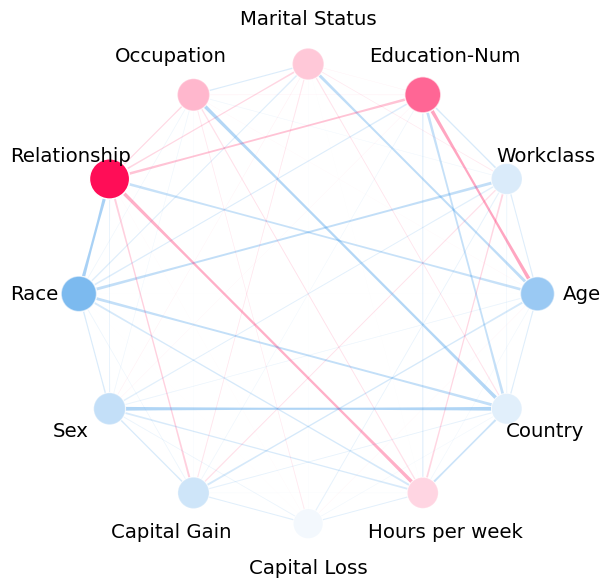

In [17]:
interaction_values.plot_network(feature_names=X_.columns.tolist())

<div class="alert alert-warning">
⚠️ <strong>Remarks</strong><br>

- Interactions do not work with **models with categorical covariates**.
- It is not the prediction that is decomposed, but rather the **class probability** (this is why the attribution do not sum to 0 or 1).
</div>